In [1]:
import numpy as np
import glob
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
f='../postp/oaat_postp.nc'
ds=xr.open_dataset(f)

In [3]:
la=xr.open_dataset('sparsegrid_landarea.nc').landarea
cf=24*60*60*365*1e-9*la.sum()

In [25]:
units={'NEP':'PgC/yr',
       'GPP':'PgC/yr',
       'EFLX_LH_TOT':'W/m2',
       'TLAI':'m2/m2'}

In [27]:
shorts={'TLAI':'LAI','EFLX_LH_TOT':'ET'}

In [4]:
expkey={'CTL2010':'Control',
        'C285':r'-CO$_2$',
        'C867':r'+CO$_2$',
        'AF1855':'PI \nClimate',
        'AF2095':'Future \nClimate',
        'NDEP':'+NDEP'}

In [44]:
def add_lab(ax,c,dx=0.05,dy=0.95):
    x1,x2=ax.get_xlim()
    y1,y2=ax.get_ylim()
    ax.text(x1+dx*(x2-x1),
            y1+dy*(y2-y1),
            '('+c+')',ha='center',va='center')

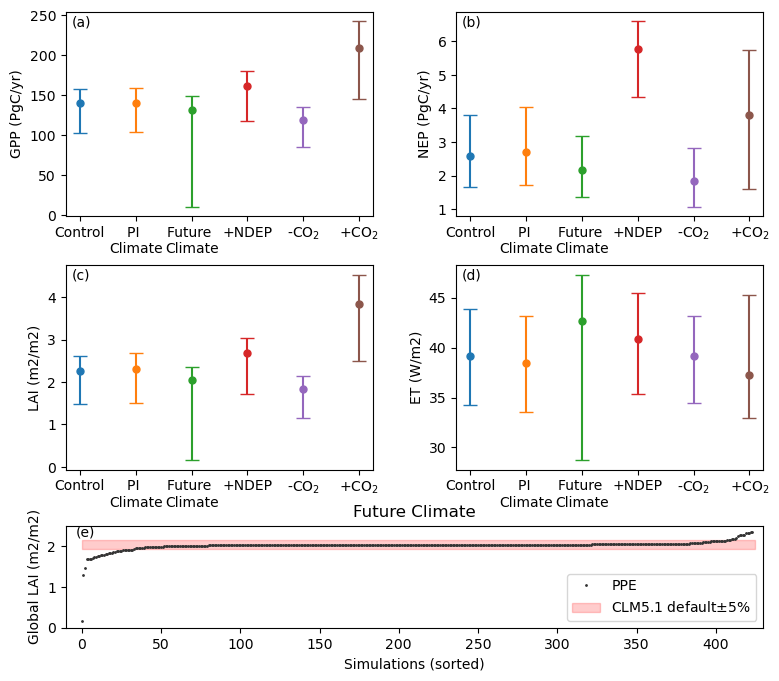

In [50]:
fig,axs=plt.subplot_mosaic('AXB;ZZZ;CVD;YYY;EEE',
                           figsize=[9,8],
                           gridspec_kw={'width_ratios': [3,0.01,3],'height_ratios': [3, 0.1,3,0.2,1.5]})
for s in 'VXYZ':
    axs[s].axis('off')

for s,v in zip('ABCD',['GPP','NEP','TLAI','EFLX_LH_TOT']):

    ax=axs[s]
    if 'P' in v:
        cf=24*60*60*365*1e-9*la.sum()
    else:
        cf=1
    if v in shorts:
        vl=shorts[v]
    else:
        vl=v
    
    for i,exp in enumerate(ds.exp):
        da=cf*ds[v+'_global_mean'].sel(exp=exp)
        xdef=da.sel(param='default',minmax='min')
        err=np.array([xdef-da.min(),da.max()-xdef]).reshape([-1,1])
        ax.errorbar([i],[xdef],err,fmt='o',ms=5,capsize=5)
    ax.set_xticks(range(6))
    ax.set_xticklabels([expkey[exp] for exp in ds.exp.values])
    ax.set_ylabel(vl+' ('+units[v]+')')
    add_lab(ax,s.lower())
        
v='TLAI'
exp='AF2095'
da=ds[v+'_global_mean'].sel(exp=exp)
x=da.values.ravel()
xdef=da.sel(param='default',minmax='min').values

s='E'
ax=axs[s]

ax.plot(sorted(x),'.',color=np.ones(3)*0.2,ms=2,label='PPE')
ax.fill_between([0,425],
                 [xdef+xdef/20,xdef+xdef/20],
                 [xdef-xdef/20,xdef-xdef/20],
                 color='r',alpha=0.2,label='CLM5.1 default$\pm$5%')
add_lab(ax,s.lower())

plt.xlim([-10,430])
plt.ylim([0,2.5])
plt.title(expkey[exp].replace('\n',''))
plt.ylabel('Global LAI (m2/m2)')
plt.xlabel('Simulations (sorted)')
plt.legend(loc=4,fontsize=10);

plt.savefig('../figs/main/ranges.png',dpi=300,bbox_inches='tight');